Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


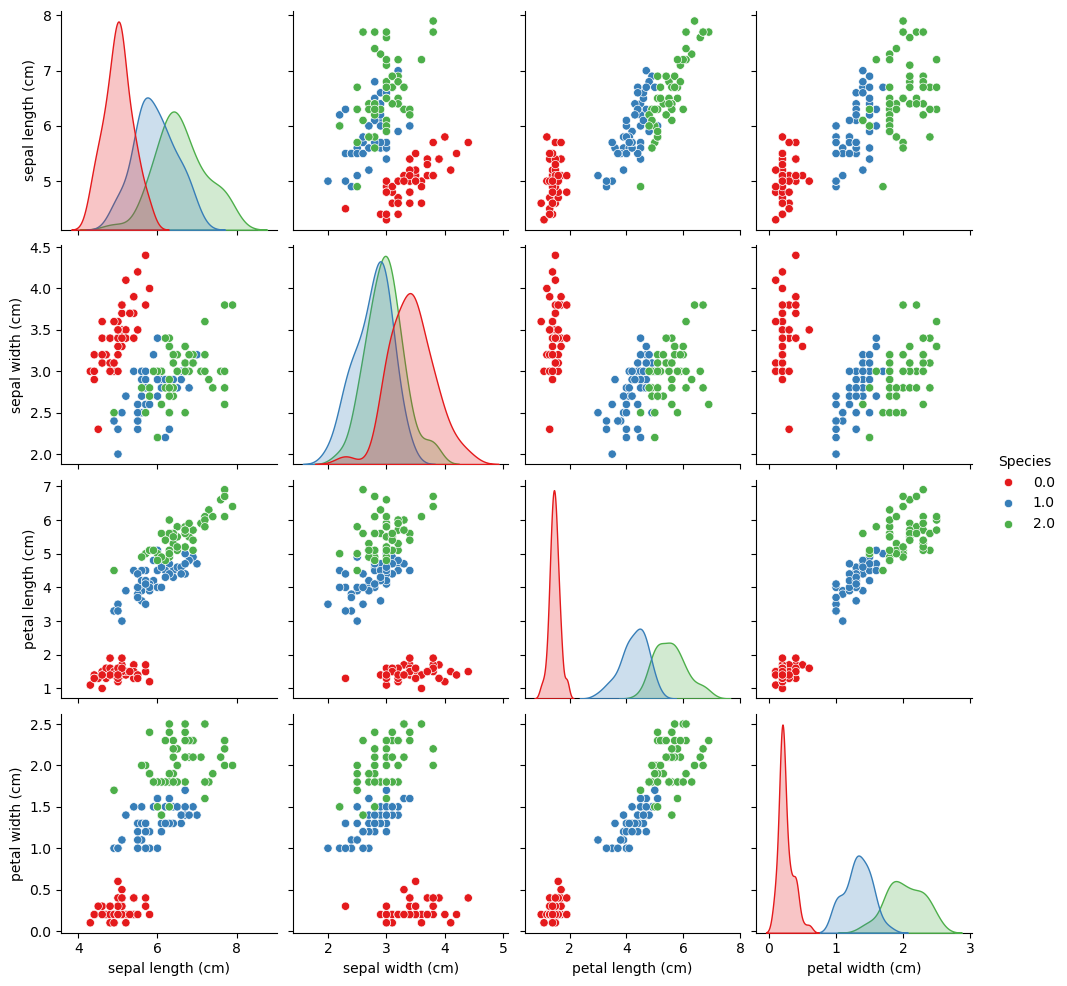


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Confusion Matrix:


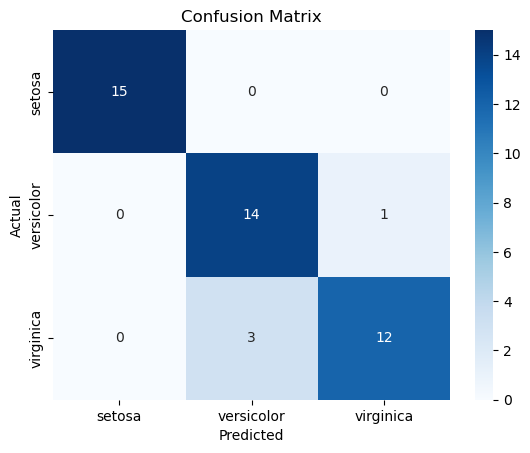

Model Accuracy: 0.91


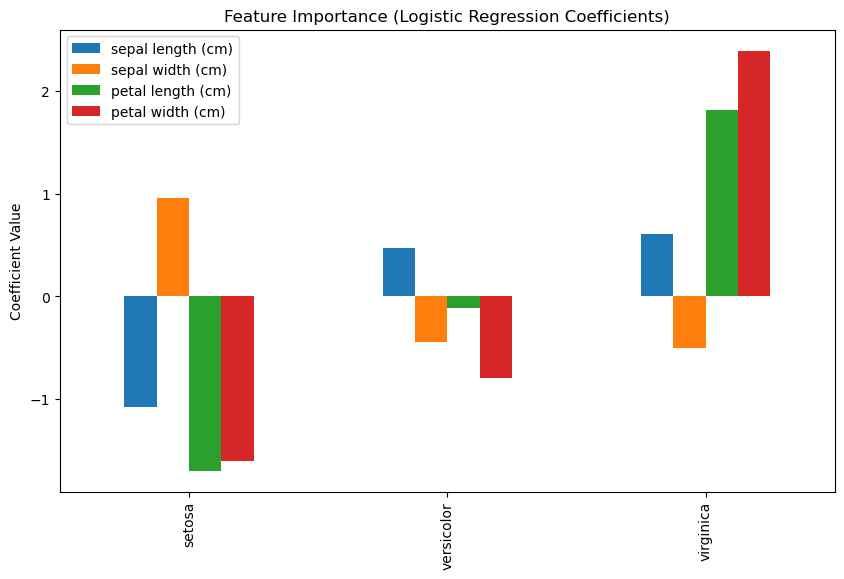

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
target_names = iris.target_names

# Display dataset information
print("Feature Names:", iris.feature_names)
print("Target Names:", target_names)

# Visualize the dataset
sns.pairplot(pd.DataFrame(np.column_stack([X, y]), columns=iris.feature_names + ['Species']),
             hue='Species', palette='Set1', diag_kind='kde')
plt.show()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Visualize feature importance
coef_df = pd.DataFrame(model.coef_, columns=iris.feature_names, index=target_names)
coef_df.plot(kind='bar', figsize=(10, 6))
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.ylabel('Coefficient Value')
plt.show()


[*********************100%***********************]  1 of 1 completed


Price        Date     Close      High       Low      Open     Volume
Ticker                 AAPL      AAPL      AAPL      AAPL       AAPL
0      2010-01-04  6.447412  6.462174  6.398306  6.429939  493729600
1      2010-01-05  6.458559  6.495012  6.424515  6.465187  601904800
2      2010-01-06  6.355828  6.484168  6.349200  6.458560  552160000
3      2010-01-07  6.344077  6.386857  6.297983  6.379325  477131200
4      2010-01-08  6.386253  6.386856  6.298284  6.335640  447610800
Mean Squared Error: 61.57
R2 Score: 0.98


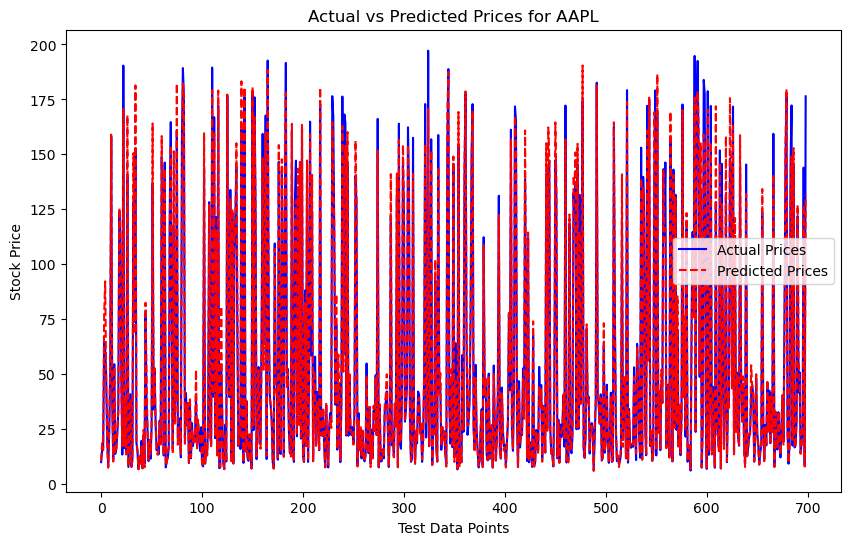

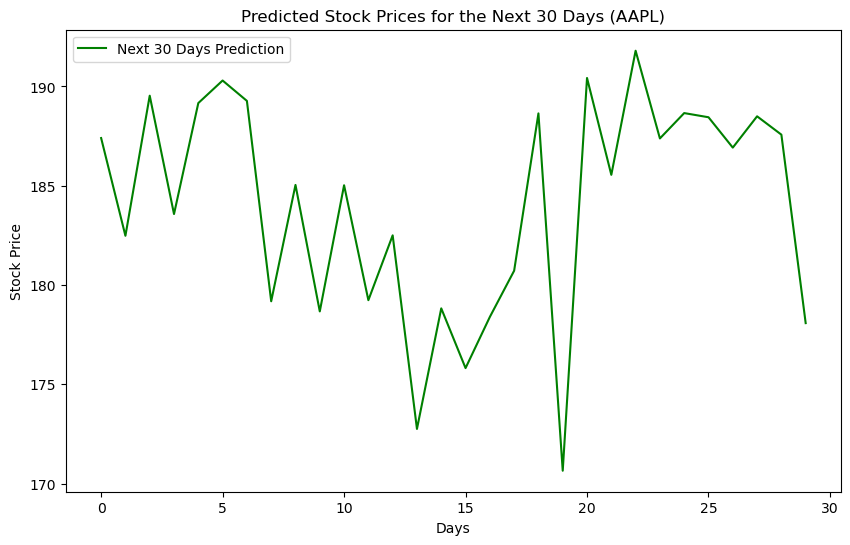

In [4]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Download historical stock price data
symbol = "AAPL"  # Replace with your desired stock symbol (e.g., "GOOG", "MSFT")
data = yf.download(symbol, start="2010-01-01", end="2023-12-31")
data.reset_index(inplace=True)

# Display the first few rows of the dataset
print(data.head())

# Feature engineering
# Use only the 'Close' price for simplicity
data['Prediction'] = data['Close'].shift(-30)  # Predict the price 30 days into the future

# Drop rows with NaN values
data = data.dropna()

# Define features (X) and target variable (y)
X = data[['Close']].values
y = data['Prediction'].values

# Scale the features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Prices', color='b')
plt.plot(predictions, label='Predicted Prices', color='r', linestyle='--')
plt.title(f"Actual vs Predicted Prices for {symbol}")
plt.xlabel('Test Data Points')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Predict the next 30 days
last_30_days = data[['Close']].iloc[-30:].values
last_30_days_scaled = scaler.transform(last_30_days)
next_30_days_prediction = model.predict(last_30_days_scaled)

# Plot the predictions for the next 30 days
plt.figure(figsize=(10, 6))
plt.plot(next_30_days_prediction, label='Next 30 Days Prediction', color='g')
plt.title(f"Predicted Stock Prices for the Next 30 Days ({symbol})")
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [3]:
!pip install yfinance


     ---------------------------------------- 0.0/948.2 kB ? eta -:--:--
     ---------------------------------------- 10.2/948.2 kB ? eta -:--:--
     -- ------------------------------------ 61.4/948.2 kB 1.1 MB/s eta 0:00:01
     ------- ------------------------------ 194.6/948.2 kB 1.7 MB/s eta 0:00:01
     ------------------ ------------------- 471.0/948.2 kB 3.3 MB/s eta 0:00:01
     -------------------------------------  942.1/948.2 kB 5.0 MB/s eta 0:00:01
     -------------------------------------- 948.2/948.2 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/104.7 kB ? eta -:--:--
   ---------------------------------------- 104.7/10

   Size  Rooms  Location   Price
0  1360      4  New York  496508
1  1794      3   Chicago  515013
2  1630      3    Boston  542967
3  1595      1    Boston  409746
4  2138      3  New York  556977
Mean Squared Error: 2057381958.075264


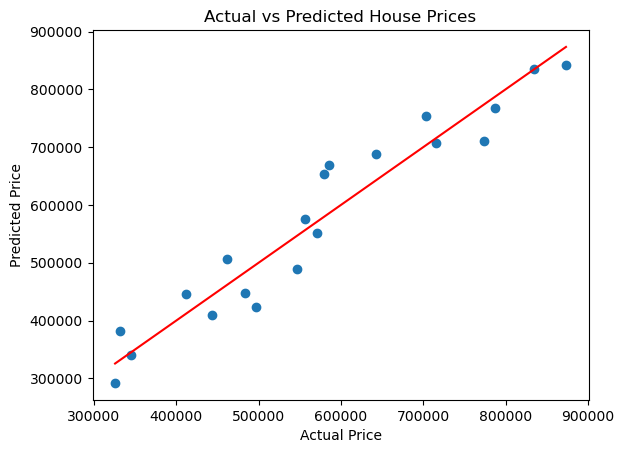

In [6]:
# Importing necessary libraries
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Create a synthetic dataset (simulating house prices)
# Assume the dataset has the columns: Size, Rooms, Location (categorical), and Price
np.random.seed(42)

# Randomly generate data for Size (in sq ft), Rooms, and Price
size = np.random.randint(500, 3500, 100)  # House size between 500 to 3500 sq ft
rooms = np.random.randint(1, 6, 100)     # Number of rooms between 1 and 5
location = np.random.choice(['New York', 'Boston', 'Chicago'], 100)  # Random locations

# Generate a price based on Size, Rooms, and Location (with some randomness)
price = (size * 200) + (rooms * 10000) + np.random.randint(50000, 200000, 100)

# Create a DataFrame
data = pd.DataFrame({
    'Size': size,
    'Rooms': rooms,
    'Location': location,
    'Price': price
})

# Display first few rows of the dataset
print(data.head())

# Preprocess the data (handle categorical 'Location' column using one-hot encoding)
data = pd.get_dummies(data, columns=['Location'], drop_first=True)

# Define the features (X) and target variable (y)
X = data[['Size', 'Rooms'] + [col for col in data.columns if col.startswith('Location_')]]
y = data['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict house prices on the test set
y_pred = model.predict(X_test)

# Calculate the Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Plotting the actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Line of perfect prediction
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()


In [7]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create a small dataset of movies
movies_data = {
    'Movie': ['The Matrix', 'Inception', 'Interstellar', 'The Dark Knight', 'Titanic', 'Avatar', 'The Godfather'],
    'Genre': ['Action|Sci-Fi', 'Action|Sci-Fi', 'Adventure|Sci-Fi', 'Action|Crime|Drama', 'Drama|Romance', 'Action|Adventure|Sci-Fi', 'Crime|Drama'],
    'Description': [
        'A computer hacker learns from mysterious rebels about the true nature of his reality and his role in the war against its controllers.',
        'A thief who enters the dreams of others to steal secrets from their subconscious is given the task of planting an idea into the mind of a CEO.',
        'A team of explorers travel through a wormhole in space in an attempt to ensure humanity\'s survival.',
        'When the menace known as The Joker emerges from his mysterious past, he wreaks havoc and chaos on the people of Gotham.',
        'A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.',
        'A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and protecting the world he feels is his home.',
        'The aging patriarch of an organized crime dynasty transfers control of his clandestine empire to his reluctant son.'
    ]
}

# Create a DataFrame
movies_df = pd.DataFrame(movies_data)

# Display the movie dataset
print("Movie Dataset:")
print(movies_df)

# Create a TF-IDF Vectorizer to convert text data into numerical vectors
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Apply the vectorizer to the 'Description' column of the dataset
tfidf_matrix = tfidf_vectorizer.fit_transform(movies_df['Description'])

# Calculate cosine similarity between the movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Function to recommend movies based on a movie the user liked
def recommend_movie(movie_title):
    # Get the index of the movie that matches the title
    idx = movies_df.index[movies_df['Movie'] == movie_title].tolist()[0]
    
    # Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort the movies based on the similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get the indices of the most similar movies (excluding the first one, which is the movie itself)
    sim_scores = sim_scores[1:4]
    
    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]
    
    # Return the top 3 most similar movies
    return movies_df['Movie'].iloc[movie_indices]

# Example: Recommend movies similar to "Inception"
recommended_movies = recommend_movie('Inception')
print("\nMovies recommended for you:")
print(recommended_movies)


Movie Dataset:
             Movie                    Genre  \
0       The Matrix            Action|Sci-Fi   
1        Inception            Action|Sci-Fi   
2     Interstellar         Adventure|Sci-Fi   
3  The Dark Knight       Action|Crime|Drama   
4          Titanic            Drama|Romance   
5           Avatar  Action|Adventure|Sci-Fi   
6    The Godfather              Crime|Drama   

                                         Description  
0  A computer hacker learns from mysterious rebel...  
1  A thief who enters the dreams of others to ste...  
2  A team of explorers travel through a wormhole ...  
3  When the menace known as The Joker emerges fro...  
4  A seventeen-year-old aristocrat falls in love ...  
5  A paraplegic Marine dispatched to the moon Pan...  
6  The aging patriarch of an organized crime dyna...  

Movies recommended for you:
0         The Matrix
2       Interstellar
3    The Dark Knight
Name: Movie, dtype: object


In [ ]:
a=5